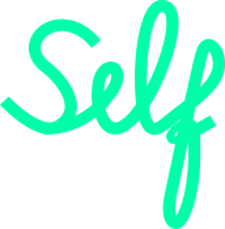


# Simulador de sueldo anual desde 2008

Este notebook simula la evolución de un sueldo anual desde 2008 hasta el año actual.

## Supuestos

- Sueldo inicial mensual en 2008: **$1.000.000 CLP**.
- El sueldo se reajusta anualmente según el IPC del año anterior.
- Se consideran **3 cambios de trabajo**.
- Cada cambio de trabajo genera un aumento adicional del **10% respecto del sueldo vigente**.
- Los cambios de trabajo se distribuyen automáticamente a lo largo del período.
- El año de inicio, 2008, se utiliza como año base y no se reajusta por IPC.
- El sueldo anual corresponde a `sueldo mensual × 12`.
- Se muestran valores nominales en pesos chilenos y valores reales expresados en pesos de 2008.

> Los IPC históricos utilizados corresponden a la variación anual del IPC general de Chile para diciembre de cada año, según la serie histórica del Banco Central de Chile basada en datos del INE. citeturn0search12turn0search13


In [1]:

# ============================================================
# 1. PARÁMETROS PRINCIPALES
# ============================================================

AÑO_INICIO = 2008
AÑO_FINAL = 2025

SUELDO_MENSUAL_INICIAL = 1_000_000
NUM_CAMBIOS_TRABAJO = 3
AUMENTO_CAMBIO_TRABAJO = 0.10

# Si quieres definir manualmente los años de cambio de trabajo,
# reemplaza None por una lista, por ejemplo:
#
# AÑOS_CAMBIO_TRABAJO = [2013, 2018, 2023]
#
# Si se deja como None, se distribuyen automáticamente.
AÑOS_CAMBIO_TRABAJO = None


In [2]:

# ============================================================
# 2. IPC ANUAL DE CHILE
# ============================================================

# Variación anual del IPC general, diciembre contra diciembre.
# Valores expresados como proporción decimal.
#
# Ejemplo:
# 7,1% -> 0.071
#
# Fuente histórica:
# Banco Central de Chile / INE
#
# 2008: 7,1%
# 2009: -1,4%
# 2010: 3,0%
# 2011: 4,4%
# 2012: 1,5%
# 2013: 3,0%
# 2014: 4,6%
# 2015: 4,4%
# 2016: 2,7%
# 2017: 2,3%
# 2018: 2,6%
# 2019: 3,0%
# 2020: 3,0%
# 2021: 7,2%
# 2022: 12,8%
# 2023: 3,9%
# 2024: 4,5%
# 2025: 3,5%

IPC_ANUAL = {
    2008: 0.071,
    2009: -0.014,
    2010: 0.030,
    2011: 0.044,
    2012: 0.015,
    2013: 0.030,
    2014: 0.046,
    2015: 0.044,
    2016: 0.027,
    2017: 0.023,
    2018: 0.026,
    2019: 0.030,
    2020: 0.030,
    2021: 0.072,
    2022: 0.128,
    2023: 0.039,
    2024: 0.045,
    2025: 0.035,
}


In [21]:

# ============================================================
# 3. IMPORTS Y FUNCIONES AUXILIARES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")


In [4]:

# ============================================================
# 4. DEFINIR LOS AÑOS DE CAMBIO DE TRABAJO
# ============================================================

años = list(range(AÑO_INICIO, AÑO_FINAL + 1))

if AÑOS_CAMBIO_TRABAJO is None:
    # Distribución automática de los cambios.
    # Se evita el primer año y el último año para que los cambios
    # ocurran durante la vida laboral simulada.
    años_disponibles = años[1:-1]

    índices = np.linspace(
        0,
        len(años_disponibles) - 1,
        NUM_CAMBIOS_TRABAJO,
        dtype=int
    )

    años_cambio_trabajo = [
        años_disponibles[i]
        for i in índices
    ]
else:
    años_cambio_trabajo = sorted(AÑOS_CAMBIO_TRABAJO)

if len(años_cambio_trabajo) != NUM_CAMBIOS_TRABAJO:
    raise ValueError(
        f"Se esperaban {NUM_CAMBIOS_TRABAJO} cambios de trabajo, "
        f"pero se definieron {len(años_cambio_trabajo)}."
    )

print("Años de cambio de trabajo:", años_cambio_trabajo)


Años de cambio de trabajo: [2009, 2016, 2024]


In [5]:

# ============================================================
# 5. SIMULACIÓN DE LA EVOLUCIÓN DEL SUELDO
# ============================================================

resultados = []

sueldo_mensual = SUELDO_MENSUAL_INICIAL

for año in años:

    # En el año base no se aplica IPC.
    # Desde el año siguiente se aplica el IPC del año anterior.
    if año > AÑO_INICIO:
        ipc_año_anterior = IPC_ANUAL[año - 1]
        sueldo_mensual *= (1 + ipc_año_anterior)

    # El cambio de trabajo ocurre sobre el sueldo ya reajustado
    # por IPC del año correspondiente.
    cambio_trabajo = año in años_cambio_trabajo

    if cambio_trabajo:
        sueldo_mensual *= (1 + AUMENTO_CAMBIO_TRABAJO)

    resultados.append({
        "Año": año,
        "IPC aplicado": 0 if año == AÑO_INICIO else IPC_ANUAL[año - 1],
        "Cambio de trabajo": cambio_trabajo,
        "Aumento cambio trabajo": AUMENTO_CAMBIO_TRABAJO if cambio_trabajo else 0,
        "Sueldo mensual": sueldo_mensual,
        "Sueldo anual": sueldo_mensual * 12,
    })

df_sueldo = pd.DataFrame(resultados)

df_sueldo.head()


,Año,IPC aplicado,Cambio de trabajo,Aumento cambio trabajo,Sueldo mensual,Sueldo anual
0,2008,0,False,0,"1,000,000","12,000,000"
1,2009,0,True,0,"1,178,100","14,137,200"
2,2010,-0,False,0,"1,161,607","13,939,279"
3,2011,0,False,0,"1,196,455","14,357,458"
4,2012,0,False,0,"1,249,099","14,989,186"


In [6]:

# ============================================================
# 6. CALCULAR SUELDO EN PESOS REALES DE 2008
# ============================================================

# Factor acumulado de inflación desde 2008 hasta cada año.
factor_inflacion = []

factor = 1.0

for año in años:
    if año > AÑO_INICIO:
        factor *= (1 + IPC_ANUAL[año - 1])

    factor_inflacion.append(factor)

df_sueldo["Factor inflación acumulada"] = factor_inflacion

# Sueldo expresado en pesos de 2008
df_sueldo["Sueldo mensual real 2008"] = (
    df_sueldo["Sueldo mensual"]
    / df_sueldo["Factor inflación acumulada"]
)

df_sueldo["Sueldo anual real 2008"] = (
    df_sueldo["Sueldo anual"]
    / df_sueldo["Factor inflación acumulada"]
)

df_sueldo


,Año,IPC aplicado,Cambio de trabajo,Aumento cambio trabajo,Sueldo mensual,Sueldo anual,Factor inflación acumulada,Sueldo mensual real 2008,Sueldo anual real 2008
0,2008,0,False,0,"1,000,000","12,000,000",1,"1,000,000","12,000,000"
1,2009,0,True,0,"1,178,100","14,137,200",1,"1,100,000","13,200,000"
2,2010,-0,False,0,"1,161,607","13,939,279",1,"1,100,000","13,200,000"
3,2011,0,False,0,"1,196,455","14,357,458",1,"1,100,000","13,200,000"
4,2012,0,False,0,"1,249,099","14,989,186",1,"1,100,000","13,200,000"
5,2013,0,False,0,"1,267,835","15,214,023",1,"1,100,000","13,200,000"
6,2014,0,False,0,"1,305,870","15,670,444",1,"1,100,000","13,200,000"
7,2015,0,False,0,"1,365,940","16,391,285",1,"1,100,000","13,200,000"
8,2016,0,True,0,"1,568,646","18,823,751",1,"1,210,000","14,520,000"
9,2017,0,False,0,"1,610,999","19,331,993",1,"1,210,000","14,520,000"


In [7]:

# ============================================================
# 7. FORMATEAR LOS RESULTADOS
# ============================================================

def formato_clp(valor):
    return f"${valor:,.0f}".replace(",", ".")

df_visual = df_sueldo.copy()

for columna in [
    "Sueldo mensual",
    "Sueldo anual",
    "Sueldo mensual real 2008",
    "Sueldo anual real 2008"
]:
    df_visual[columna] = df_visual[columna].apply(formato_clp)

df_visual["IPC aplicado"] = (
    df_sueldo["IPC aplicado"] * 100
).map(lambda x: f"{x:.1f}%")

df_visual["Aumento cambio trabajo"] = (
    df_sueldo["Aumento cambio trabajo"] * 100
).map(lambda x: f"{x:.0f}%")

df_visual


,Año,IPC aplicado,Cambio de trabajo,Aumento cambio trabajo,Sueldo mensual,Sueldo anual,Factor inflación acumulada,Sueldo mensual real 2008,Sueldo anual real 2008
0,2008,0.0%,False,0%,$1.000.000,$12.000.000,1,$1.000.000,$12.000.000
1,2009,7.1%,True,10%,$1.178.100,$14.137.200,1,$1.100.000,$13.200.000
2,2010,-1.4%,False,0%,$1.161.607,$13.939.279,1,$1.100.000,$13.200.000
3,2011,3.0%,False,0%,$1.196.455,$14.357.458,1,$1.100.000,$13.200.000
4,2012,4.4%,False,0%,$1.249.099,$14.989.186,1,$1.100.000,$13.200.000
5,2013,1.5%,False,0%,$1.267.835,$15.214.023,1,$1.100.000,$13.200.000
6,2014,3.0%,False,0%,$1.305.870,$15.670.444,1,$1.100.000,$13.200.000
7,2015,4.6%,False,0%,$1.365.940,$16.391.285,1,$1.100.000,$13.200.000
8,2016,4.4%,True,10%,$1.568.646,$18.823.751,1,$1.210.000,$14.520.000
9,2017,2.7%,False,0%,$1.610.999,$19.331.993,1,$1.210.000,$14.520.000


In [13]:

# ============================================================
# 8. RESUMEN DE LA SIMULACIÓN
# ============================================================

sueldo_inicial = df_sueldo.iloc[0]["Sueldo mensual"]
sueldo_final = df_sueldo.iloc[-1]["Sueldo mensual"]

crecimiento_nominal = sueldo_final / sueldo_inicial - 1

sueldo_final_real_2008 = df_sueldo.iloc[-1]["Sueldo mensual real 2008"]
crecimiento_real = sueldo_final_real_2008 / sueldo_inicial - 1

inflacion_acumulada = (
    df_sueldo.iloc[-1]["Factor inflación acumulada"] - 1
)

resumen = pd.Series({
    "Sueldo mensual inicial": formato_clp(sueldo_inicial),
    "Sueldo mensual final nominal": formato_clp(sueldo_final),
    "Sueldo mensual final en pesos de 2008": formato_clp(sueldo_final_real_2008),
    "Crecimiento nominal del sueldo": f"{crecimiento_nominal:.1%}",
    "Crecimiento real del sueldo": f"{crecimiento_real:.1%}",
    "Inflación acumulada": f"{inflacion_acumulada:.1%}",
    "Número de cambios de trabajo": NUM_CAMBIOS_TRABAJO,
    "Años de cambio de trabajo": ", ".join(map(str, años_cambio_trabajo)),
    "Ingresos totales": formato_clp(df_sueldo["Sueldo anual"].sum())
})

resumen


,0
Sueldo mensual inicial,$1.000.000
Sueldo mensual final nominal,$2.590.724
Sueldo mensual final en pesos de 2008,$1.331.000
Crecimiento nominal del sueldo,159.1%
Crecimiento real del sueldo,33.1%
Inflación acumulada,94.6%
Número de cambios de trabajo,3
Años de cambio de trabajo,"2009, 2016, 2024"
Ingresos totales,$347.293.453


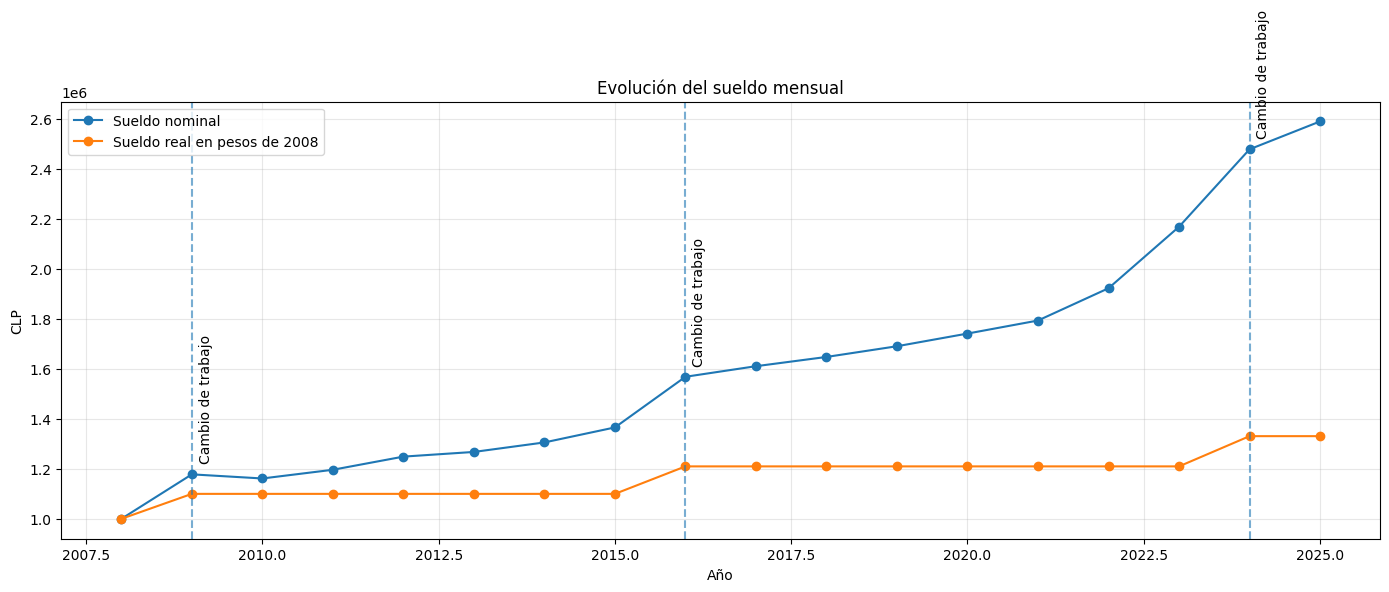

In [9]:

# ============================================================
# 9. GRÁFICO DEL SUELDO MENSUAL
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    df_sueldo["Año"],
    df_sueldo["Sueldo mensual"],
    marker="o",
    label="Sueldo nominal"
)

plt.plot(
    df_sueldo["Año"],
    df_sueldo["Sueldo mensual real 2008"],
    marker="o",
    label="Sueldo real en pesos de 2008"
)

for año in años_cambio_trabajo:
    sueldo = df_sueldo.loc[
        df_sueldo["Año"] == año,
        "Sueldo mensual"
    ].iloc[0]

    plt.axvline(
        año,
        linestyle="--",
        alpha=0.6
    )

    plt.annotate(
        "Cambio de trabajo",
        xy=(año, sueldo),
        xytext=(5, 10),
        textcoords="offset points",
        rotation=90
    )

plt.title("Evolución del sueldo mensual")
plt.xlabel("Año")
plt.ylabel("CLP")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


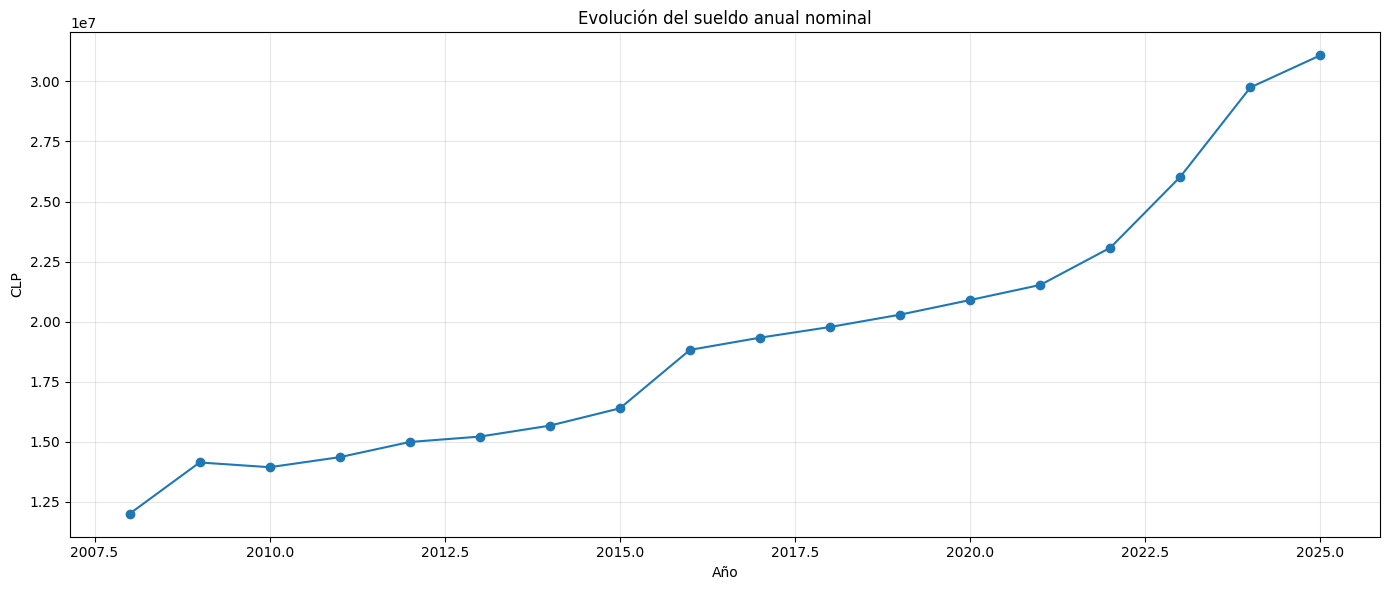

In [19]:

# ============================================================
# 10. GRÁFICO DEL SUELDO ANUAL
# ============================================================
def formato_clp(x, pos):
    return f"${x:,.0f}".replace(",", ".")

plt.figure(figsize=(14, 6))

plt.plot(
    df_sueldo["Año"],
    df_sueldo["Sueldo anual"],
    marker="o"
)

plt.title("Evolución del sueldo anual nominal")
plt.xlabel("Año")
plt.ylabel("CLP")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


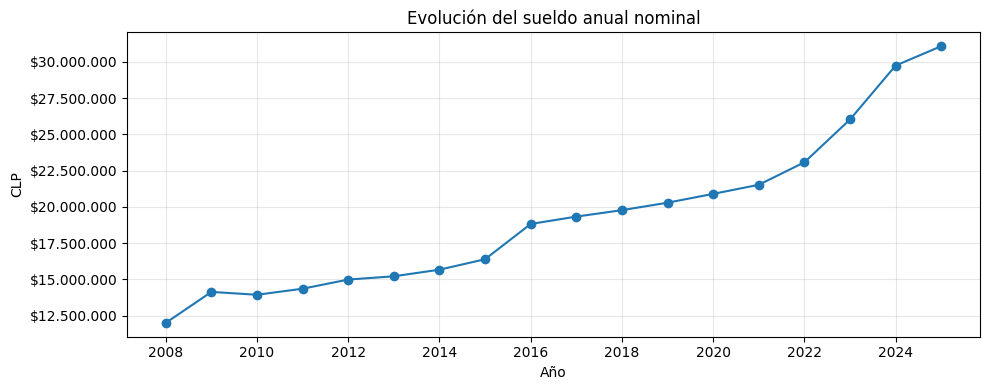

In [22]:
def formato_clp(x, pos):
    return f"${x:,.0f}".replace(",", ".")

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    df_sueldo["Año"],
    df_sueldo["Sueldo anual"],
    marker="o"
)

ax.set_title("Evolución del sueldo anual nominal")
ax.set_ylabel("CLP")

ax.set_xlabel("Año")
ax.set_ylabel("CLP")
ax.grid(True, alpha=0.3)

# Mostrar únicamente años enteros en el eje X
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# Formato de pesos chilenos
ax.yaxis.set_major_formatter(FuncFormatter(formato_clp))

plt.tight_layout()
plt.show()

In [12]:
df_sueldo["Sueldo anual"].sum()

np.float64(347293452.8008246)

In [11]:

# ============================================================
# 11. DESCOMPOSICIÓN DE LA EVOLUCIÓN DEL SUELDO
# ============================================================

df_sueldo["Sueldo mensual año anterior"] = (
    df_sueldo["Sueldo mensual"].shift(1)
)

df_sueldo["Variación sueldo nominal"] = (
    df_sueldo["Sueldo mensual"]
    / df_sueldo["Sueldo mensual año anterior"]
    - 1
)

df_sueldo[
    [
        "Año",
        "IPC aplicado",
        "Cambio de trabajo",
        "Variación sueldo nominal",
        "Sueldo mensual",
    ]
]


,Año,IPC aplicado,Cambio de trabajo,Variación sueldo nominal,Sueldo mensual
0,2008,0,False,NaN,"1,000,000"
1,2009,0,True,0,"1,178,100"
2,2010,-0,False,-0,"1,161,607"
3,2011,0,False,0,"1,196,455"
4,2012,0,False,0,"1,249,099"
5,2013,0,False,0,"1,267,835"
6,2014,0,False,0,"1,305,870"
7,2015,0,False,0,"1,365,940"
8,2016,0,True,0,"1,568,646"
9,2017,0,False,0,"1,610,999"



## Cómo modificar el simulador

### Cambiar sueldo inicial

```python
SUELDO_MENSUAL_INICIAL = 1_500_000
```

### Cambiar el número de cambios de trabajo

```python
NUM_CAMBIOS_TRABAJO = 5
```

### Cambiar el aumento por cambio de trabajo

```python
AUMENTO_CAMBIO_TRABAJO = 0.15
```

### Definir manualmente los años de cambio

```python
AÑOS_CAMBIO_TRABAJO = [2012, 2018, 2024]
```

La simulación aplica primero el reajuste por IPC y luego el aumento correspondiente al cambio de trabajo durante ese año.
